# Personal Docente Investigador UCM

Usa la librería que prefieras (recomiendo Plotly ó Matplotlib) para realizar los ejercicios sobre el conjunto de datos del PDI UCM.

Ahora tu objetivo no es conseguir un resultado concreto, sino proporcionar un vistazo general de un conjunto de datos real - en este caso, el PDI (Personal Docente e Investigador) de esta Universidad. Ojo porque los datos están anonimizados - lee más sobre ello en https://dimetrical.atlassian.net/wiki/spaces/UNC/pages/515571713 (o mira el leeme para más URLs).

TL/DR: La anonimización aplicada *permite* agrupar por departamento y/o género y, aunque esté todo mezclado dentro, mostrar visualizaciones correctas.

## Realizando los ejercicios

Para contestar **cada apartado de cada ejercicio**, debes generar **1 visualización + un texto corto** (no más de 20 palabras) que explica cómo contesta tu visualización a ese apartado. No vale sólo con la visualización o con el texto: la visualización debe *mostrar tu respuesta*, y el texto debe decir *cómo y dónde se ve esa respuesta*.

Nombre 1: Iván García Vallejo
Nombre 2: David Rodríguez De la O

In [25]:
# carga de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df_19 = pd.read_csv('data/ucm-personal-pdi-2019-anonimizado.csv') # anio = 2019
df_24 = pd.read_csv('data/ucm-personal-pdi-2024-anonimizado.csv') # anio = 2024
df_all = pd.concat([df_19, df_24], ignore_index=True)
display(df_all.head())


,IMPORTANTE,cod_universidad,des_universidad,anio,cod_pais_nacionalidad,des_pais_nacionalidad,lat_pais_nacionalidad,lon_pais_nacionalidad,cod_continente_nacionalidad,des_continente_nacionalidad,...,des_unidad_responsable,cod_area_conocimiento,des_area_conocimiento,anio_incorporacion_ap,anio_incorpora_cuerpo_docente,num_trienios,num_quinquenios,num_sexenios,num_tesis,ind_investigador_principal
0,LOS DATOS DE ESTA FILA NO CORRESPONDEN A UN SÓ...,10,Universidad Complutense de Madrid,2019,724,España,40.463667,-3.74922,150,Europa,...,"Economía Aplicada, Pública y Política",225.0,Economía Aplicada,1974.0,1983.0,14,6,5,0,S
1,LOS DATOS DE ESTA FILA NO CORRESPONDEN A UN SÓ...,10,Universidad Complutense de Madrid,2019,724,España,40.463667,-3.74922,150,Europa,...,"Economía Aplicada, Pública y Política",225.0,Economía Aplicada,1993.0,1999.0,7,3,2,0,N
2,LOS DATOS DE ESTA FILA NO CORRESPONDEN A UN SÓ...,10,Universidad Complutense de Madrid,2019,724,España,40.463667,-3.74922,150,Europa,...,"Economía Aplicada, Pública y Política",225.0,Economía Aplicada,2001.0,2019.0,6,1,1,1,N
3,LOS DATOS DE ESTA FILA NO CORRESPONDEN A UN SÓ...,10,Universidad Complutense de Madrid,2019,724,España,40.463667,-3.74922,150,Europa,...,"Economía Aplicada, Pública y Política",225.0,Economía Aplicada,1992.0,1992.0,11,6,4,0,N
4,LOS DATOS DE ESTA FILA NO CORRESPONDEN A UN SÓ...,10,Universidad Complutense de Madrid,2019,724,España,40.463667,-3.74922,150,Europa,...,"Economía Aplicada, Pública y Política",225.0,Economía Aplicada,NaN,NaN,7,2,0,0,S


## Ejercicio 1: departamentos y sus tamaños

a. ¿cuántos departamentos hay en 2024? 

b. ¿cuál es su tamaño típico? ¿hay montones de microdepartamentos y alguno realmente enorme, o son todos de tamaño similar? 

c. ¿cómo han cambiado estos datos con respecto a 2019?

In [26]:
# comienzo de solucion: departamentos en 2024
print("a) En 2024 hay" , len(df_24['des_unidad_responsable'].value_counts()), "departamentos.")

a) En 2024 hay 99 departamentos.


b) En la siguiente gráfica observamos que hay 1 departamento que supera las 350 personas, 
hay 8 con entre 100 y 350 y 90 se encuentran entre 22 y 100 


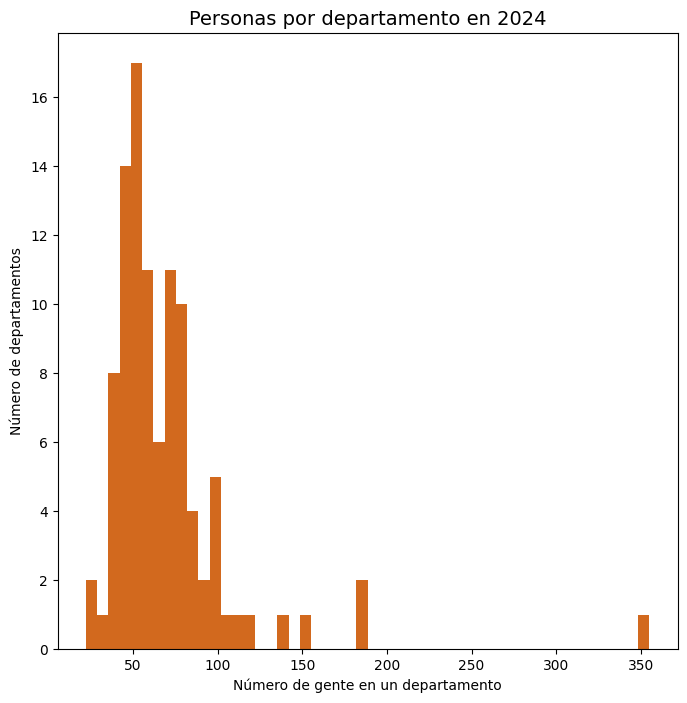

In [27]:
print("b) En la siguiente gráfica observamos que hay", sum(df_24['des_unidad_responsable'].value_counts() > 350),   "departamento que supera las 350 personas, " \
"\nhay", sum(df_24['des_unidad_responsable'].value_counts().between(100,350)),  "con entre 100 y 350 y", sum(df_24['des_unidad_responsable'].value_counts() < 100), "se encuentran entre", df_24['des_unidad_responsable'].value_counts().min() ,"y 100 ")
plt.figure(figsize=(8,8))
plt.hist(x = df_24['des_unidad_responsable'].value_counts(), bins = 50, color = "Chocolate")
plt.xlabel("Número de gente en un departamento")
plt.ylabel("Número de departamentos")
plt.title('Personas por departamento en 2024', fontsize=14)
plt.show()

c) Observamos que en 2019 había una gran cantidad de departamentos con 50 personas aprox, valor 
que se ha reducido un poco en 2024 y que parece aumentar en los departamentos con 100 personas aprox. 


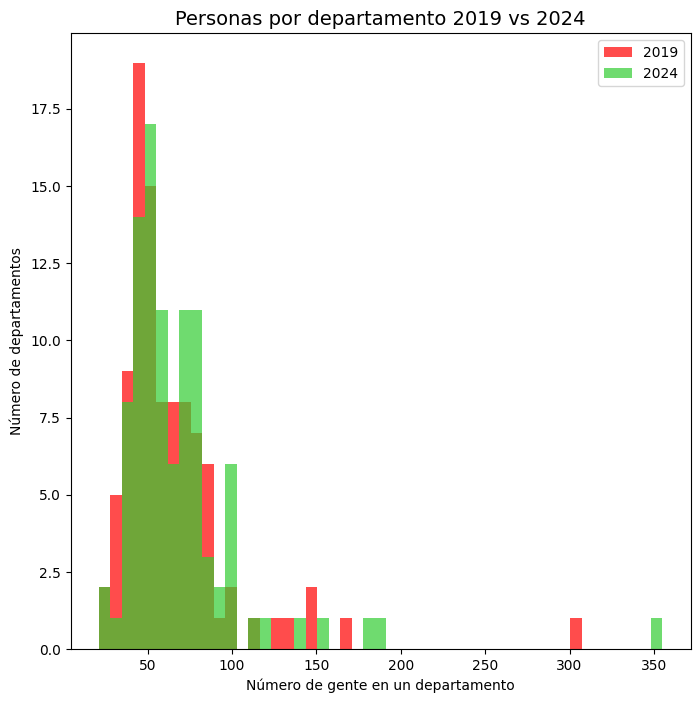

In [28]:
print("c) Observamos que en 2019 había una gran cantidad de departamentos con 50 personas aprox, valor " \
"\nque se ha reducido un poco en 2024 y que parece aumentar en los departamentos con 100 personas aprox. ")

valores_2024 = df_24['des_unidad_responsable'].value_counts()
valores_2019 = df_19['des_unidad_responsable'].value_counts()

min_global = min(valores_2019.min(), valores_2024.min())
max_global = max(valores_2019.max(), valores_2024.max())
bins_comunes = np.linspace(min_global, max_global, 50)

plt.figure(figsize=(8,8))
plt.hist(valores_2019, bins = bins_comunes, alpha = 0.7, color = "Red", label = 2019 )
plt.hist(valores_2024, bins = bins_comunes, alpha = 0.7, color = "LimeGreen", label = 2024 )
plt.xlabel("Número de gente en un departamento")
plt.ylabel("Número de departamentos")
plt.title('Personas por departamento 2019 vs 2024', fontsize=14)
plt.legend()
plt.show()

## Ejercicio 2: edad media del PDI por departamento

Para este ejercicio, considera sólo personal en servicio activo (cod_situacion_administrativa=1)

a. ¿cómo están distribuidas las edades en el conjunto de PDI de la UCM en 2024? ¿cómo ha cambiado esto con respecto a 2019?

b. ¿hay diferencias significativas por departamentos, o están todos igual de envejecidos? 

c. Estás pensando hacerte profesor de algo: ¿qué departamentos tendrán más vacantes de aquí a 5 años, asumiendo que intentan mantener el tamaño de hace 5 años, y dadas las vacantes generadas en estos últimos 5 años?

In [29]:
# comiezo de solución: edades en 2024
df_24 = df_24[df_24['cod_situacion_administrativa'] == 1]
df_19 = df_19[df_19['cod_situacion_administrativa'] == 1]
df_24['edad'] = 2025 - df_24['anio_nacimiento']
df_19['edad'] = 2025 - df_19['anio_nacimiento']




a) Como podemos observar en los diagramas, en 2019 la mayoría de personas 
tenían entre un poco más de 50 años y 65.
En cambio, en 2024 las edades más comunes se encuentran entre un poco menos de 50 y los 60 años.
Además, tanto la media como la mediana han pasado de estar más cerca de los 60 a estarlo de los 50


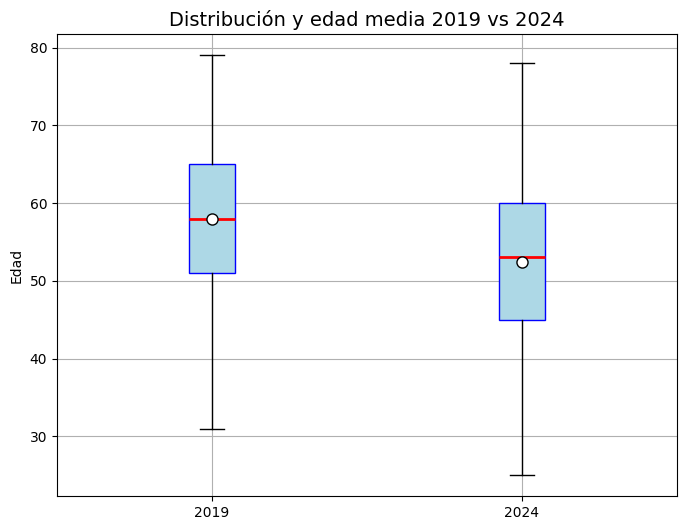

In [30]:
print("a) Como podemos observar en los diagramas, en 2019 la mayoría de personas " \
"\ntenían entre un poco más de 50 años y 65." \
"\nEn cambio, en 2024 las edades más comunes se encuentran entre un poco menos de 50 y los 60 años." \
"\nAdemás, tanto la media como la mediana han pasado de estar más cerca de los 60 a estarlo de los 50")
plt.figure(figsize=(8,6))
plt.boxplot([df_19['edad'],df_24['edad']], 
            tick_labels = [2019, 2024],
            showmeans = True,
            meanprops={                    
            "marker": "o", 
            "markerfacecolor": "white", 
            "markeredgecolor": "black",
            "markersize": "8"
            },
            patch_artist=True,             
            boxprops=dict(facecolor='lightblue', color='blue'), 
            medianprops=dict(color='red', linewidth=2))
plt.ylabel("Edad")
plt.grid()
plt.title('Distribución y edad media 2019 vs 2024', fontsize=14)
plt.show()


b) Podemos observar que hay un departamento que destaca por tener una edad media de 59 años.
Por otro lado, vemos que la tendencia es a una edad media de 


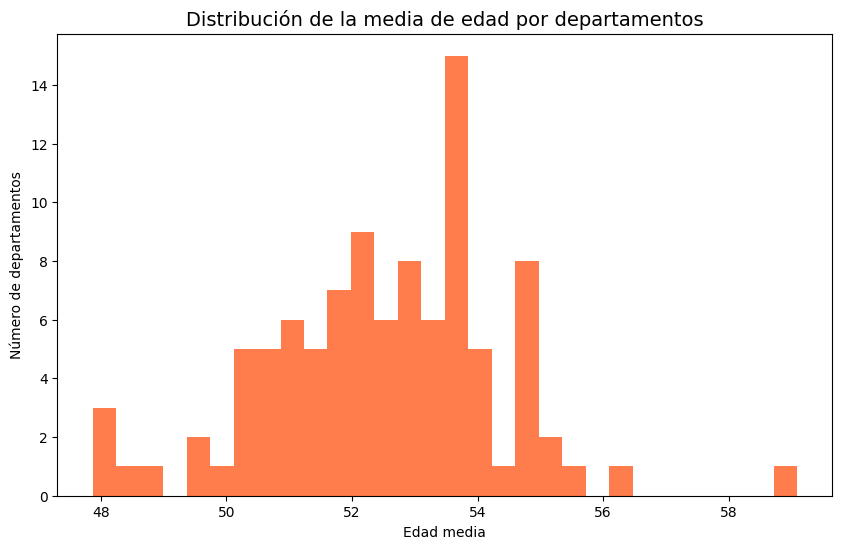

In [31]:
print("b) Podemos observar que hay un departamento que destaca por tener una edad media de 59 años." \
"\nPor otro lado, vemos que la tendencia es a una edad media de ")
departamentos_media = df_24.groupby('des_unidad_responsable')['edad'].mean()
departamentos_mediana = df_24.groupby('des_unidad_responsable')['edad'].median()

plt.figure(figsize=(10,6))
plt.hist(departamentos_media, bins = 30, color = "OrangeRed", alpha = 0.7)
plt.xticks([48,50,52,54,56,58])
plt.xlabel("Edad media")
plt.ylabel("Número de departamentos")
plt.title("Distribución de la media de edad por departamentos", fontsize=14)
plt.show()



c) Podemos observar que en 'Organización de Empresas y Marketing' han quedado libres cerca de 70 plazas.
Vemos que las demás no superan las 10 plazas disponibles.


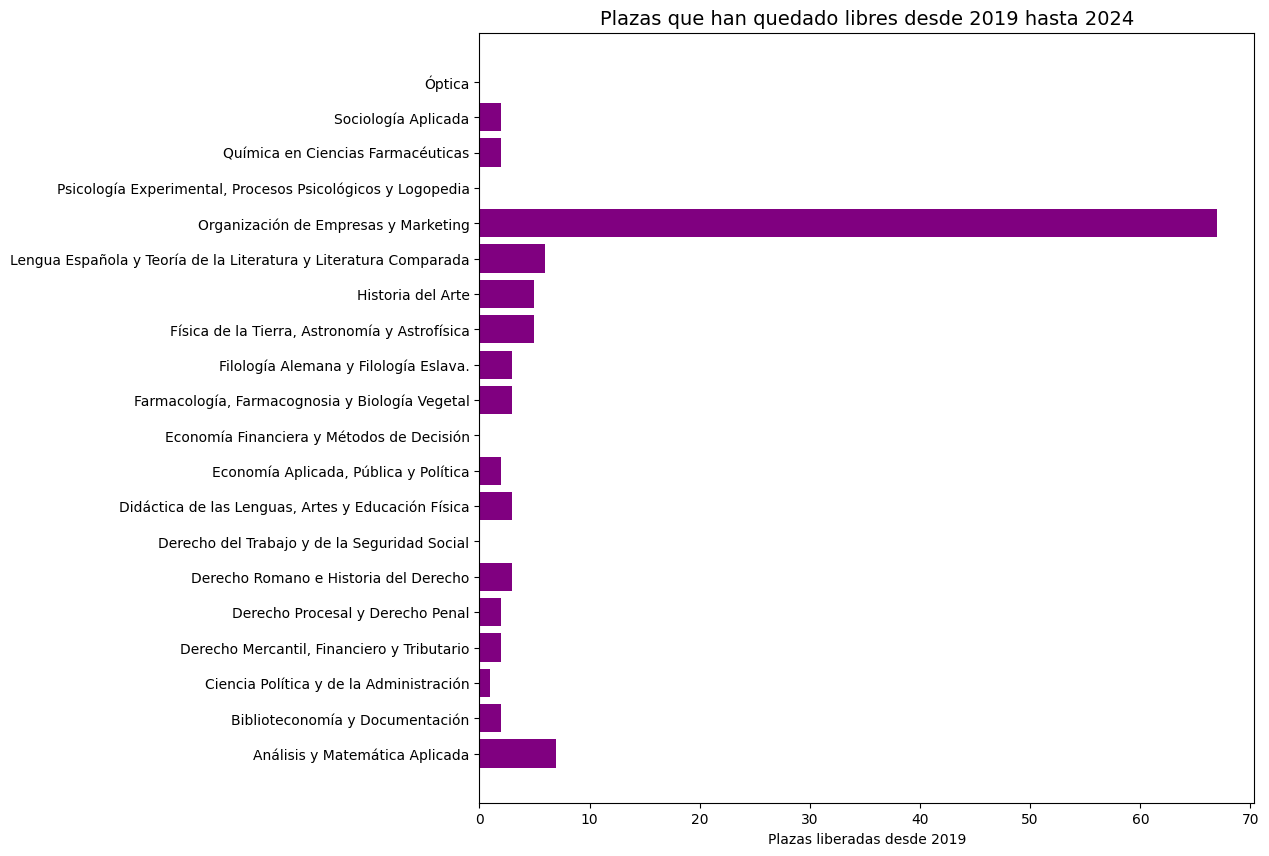

In [32]:
print("c) Podemos observar que en 'Organización de Empresas y Marketing' han quedado libres cerca de 70 plazas." \
"\nVemos que las demás no superan las 10 plazas disponibles.")
valores_2024 = df_24['des_unidad_responsable'].value_counts()
valores_2019 = df_19['des_unidad_responsable'].value_counts()
diferencias = valores_2019 - valores_2024
diferencias = diferencias[diferencias >= 0] #Solo dejamos los departamentos que han perdido gente.
plt.figure(figsize=(10,10))
plt.barh(diferencias.index, width = diferencias.values, color = "purple")
plt.xlabel("Plazas liberadas desde 2019")
plt.title("Plazas que han quedado libres desde 2019 hasta 2024", fontsize = 14)
plt.show()